

## Acceptance probability
$$\alpha = min(1, \text{likelihood ratio} \times \text{prior ratio} \times \text{proposal ratio})$$
$$\alpha = min(1, \frac{L_{k'}(\mu=1)L_1(\mu=0)}{L_1(\mu=1)L_{k'}(\mu=0)} \frac{\pi(k')}{\pi(k)} \frac{\pi(\theta'_{k'}|k')}{\pi(\theta_{k}|k)} q_{total})$$
$$\alpha = min(1, \exp\{\log{\frac{L_{k'}(\mu=1)L_1(\mu=0)}{L_1(\mu=1)L_{k'}(\mu=0)}} + \frac{\pi(k')}{\pi(k)} \frac{\pi(\theta'_{k'}|k')}{\pi(\theta_{k}|k)} + \log{q_{total}}\})$$


I had earlier forgotten about the prior ratio of the parameters given the model $\frac{\pi(\theta'_{k'}|k')}{\pi(\theta_{k}|k)}$. While we initialize the new parameters (if the dimension changes), if we draw the random numbers from the prior distribution, it would ultimately cancel in the acceptance ratio.

(I got this idea from slide 19 (point 4) and slide 33 of this very nice set of slides on RJMCMC https://www.math.mcgill.ca/dstephens/598-Bayes-2018/Handouts/Math598-MCMC-Lectures-III.pdf)

## Changing model
Model at step i: manipulator.M; Ex:[X1Z, X1W]
$\\$
Propose model at step i+1: manipulator.propose_model

#### Move 1: Unfreezing a particle
Propose unfreezing of X2Z
$\\$-> Initialize mass of X2Z:
$\\ \quad$    -> Draw random number $m_r \sim Uni[0,1]$
$\\ \quad$    -> $(m_{X1Z}, m_{X1W}, m_r) \rightarrow (m_{X1Z}, m_{X1W}, m_{X2Z}); m_{X2Z} = m_{X1Z} + (m_{max} - m_{X1Z})m_r$ 
$\\ \quad$  -> $|J|^{un}_{m_{X2Z}} = \partial m_{X2Z}/ \partial m_{r} = m_{max} - m_{X1Z}$
$\\ \quad$ -> $p(m_r) = I_{[0,1]}$

$\\$
$\\\\$-> Initialize decays of X2Z:
$\\ \quad$    -> Draw random number $b_r \sim Gauss(1/n_{dc},\sqrt{0.5/n_{dc}})$ for each decay channel
$\\ \quad$    -> $(\{b_{X1W}\}, \{b_r\}) \rightarrow (\{b_{X1W}\}, \{b_{X2Z}\}); b_{X2Z} = b_{r}$
$\\ \quad$  -> $|J|^{un}_{b_{X2Z}} = \partial b_{X2Z}/ \partial b_{r} = 1.0$
$\\ \quad$ -> $p(b_r) = Gauss(b_r|1/n_{dc},\sqrt{0.5/n_{dc}}) $

$\\$
$\\\\$-> Initialize prod modes of X2Z:
$\\ \quad$    -> Draw random number $s_r \sim Lognorm(1.0,\sigma)$ for each prod mode
$\\ \quad$    -> $(\{s_{X1W}\}, \{s_r\}) \rightarrow (\{s_{X1W}\}, \{s_{X2Z}\}); s_{X2Z} = s_{r}$
$\\ \quad$  -> $|J|^{un}_{s_{X2Z}} = \partial s_{X2Z}/ \partial s_{r} = 1.0$
$\\ \quad$ -> $p(s_r) = Lognorm(s_r|1.0,\sigma) $

$\\$
$\\\\$-> Check with probability to unfreeze new degrees of freedom:
$$q_{add}(i\rightarrow i+1) = \frac{sigmoid( -z_{i+1})}{sigmoid( -z_{i})}= \frac{1+\exp(z_i)}{1+\exp(z_{i+1})}; \quad\quad dim(i)<dim(i+1)$$
$\\ \quad$    -> Draw random number $u \sim Uni[0,1]$
$\\ \quad$    ->if $u > q(i\rightarrow i+1)$, reject unfreezing of X2Z, undo the changes made in propose_model,  total proposal ratio of the move $\quad\quad q_{un} = 1$
$\\ \quad$    ->else, accept unfreezing of X2Z, calculate the total proposal ratio of the move

$$ q_{un} = \frac{q_{rem}(i+1 \rightarrow i)}{q_{add}(i\rightarrow i+1)} \frac{1}{p(m_r)p(b_r)p(s_r)}|J|^{un}_{m_{X2Z}}$$

$\\$ Prior for mass = $Uni[m_{LSP}, maxmass]$
$\\$ Prior for br = $Gauss(1/n_{dc},\sqrt{0.5/n_{dc}})$
$\\$ Prior for ssm =  $Lognorm(1.0,\sigma)$
$\\$ Prior ratio (for mass) = $\frac{\pi(m_{X1Z})\pi(m_{X1W})\pi(m_{X2Z})}{\pi(m_{X1Z})\pi(m_{X1W})} = \pi(m_{X2Z})$
$\\$ Similarly, prior ratio for br and ssm  = $\pi(b_{X2Z})\pi(s_{X2Z})$

These densities would cancel with the proposal densities for the new parameters as they are from the same distribution

$$ \text{Prior ratio for parameters} \times \text{proposal ratio} =  \frac{q_{rem}(i+1 \rightarrow i)}{q_{add}(i\rightarrow i+1)}

### $z_i$
$z_i$ is inspired from the penalty on model complexity
$$z_{i} = (\frac{n_{p}-8}{a} + \frac{n_{d}}{b} + \frac{n_{s}}{c})_{i}$$

#### Move 2: Freezing a particle
Propose freezing of X1W
$\\$-> Remove mass of X1W: 
$\\ \quad$    -> $(m_{X1Z}, m_{X1W}) \rightarrow (m_{X1Z}, m_{r}); m_{X1W} = m_{X1Z} + (m_{max} - m_{X1Z})m_r$ 
$\\ \quad$  -> $|J|^{fr}_{m_{X1W}} = \partial m_{r}/ \partial m_{X_{X1W}} = 1/(m_{max} - m_{X1Z})$
$\\ \quad$ -> $p(m_r) = I_{[0,1]} \quad m_r \sim Uni[0,1]$

$\\$
$\\\\$-> Remove decays of X1W:
$\\ \quad$    -> $  (\{b_{X1W}\}) \rightarrow (\{b_{r}\}) ; b_{X1W} = b_{r}$
$\\ \quad$  -> $|J|^{fr}_{b_{X1W}} = \partial b_{r}/ \partial b_{X1W} = 1.0$
$\\ \quad$ -> $p(b_r) = Gauss(b_r|1/n_{dc},\sqrt{0.5/n_{dc}}) $

$\\$
$\\\\$-> Initialize prod modes of X1W:
$\\ \quad$    -> $(\{s_{X1W}\}) \rightarrow (\{s_{r}\}); s_{X1W} = s_{r}$
$\\ \quad$  -> $|J|^{fr}_{s_{X1W}} = \partial s_{r}/ \partial s_{X1W} = 1.0$
$\\ \quad$ -> $p(s_r) = Lognorm(s_r|1.0,\sigma) $

$\\$
$\\\\$-> Check with probability to freeze new degrees of freedom:
$$q_{rem}(i \rightarrow i+1) = \frac{sigmoid( z_{i})}{sigmoid( z_{i+1})}= \frac{1+\exp(-z_{i+1})}{1+\exp(-z_{i})}; \quad\quad dim(i)>dim(i+1)$$
$\\ \quad$    -> Draw random number $u \sim Uni[0,1]$
$\\ \quad$    ->if $u > q_{rem}(i\rightarrow i+1)$, reject freezing of X1W, undo the changes made in propose_model,  total proposal ratio of the move $\quad\quad q_{fr} = 1$
$\\ \quad$    ->else, accept freezing of X1W, calculate the total proposal ratio of the move

$$ q_{fr} = \frac{q_{add}(i+1 \rightarrow i)}{q_{rem}(i\rightarrow i+1)} \frac{p(m_r)p(b_r)p(s_r)}{1}|J|^{fr}_{m_{X1W}}$$


$$ \text{Prior ratio for parameters} \times \text{proposal ratio} =  \frac{q_{add}(i+1 \rightarrow i)}{q_{rem}(i\rightarrow i+1)}



#### Move 3: Removing decay of a particle
Propose removing br of X1W
$\\$ -> Chance of keeping only one decay channel $= 0.05  = p(rem)$
$\\$ -> Chance of removing one decay channel $= 0.05 = p(rem)$
$\\$ -> Chance of adding decay channel = $0.9 * (Gauss(0;n_{dc},\sqrt{0.5/n_{dc}}) + 0.1) = p(add)$
$\\ \quad$    -> $  (\{b_{X1W}\}) \rightarrow (\{b_{r}\}) ; b_{X1W} = b_{r}$
$\\ \quad$  -> $|J|^{fr}_{b_{X1W}} = \partial b_{r}/ \partial b_{X1W} = 1.0$
$\\ \quad$ -> $p(b_r) = Gauss(b_r|1/n_{dc},\sqrt{0.5/n_{dc}}) $

$\\$
$\\\\$-> Check with probability to remove degrees of freedom:
$$q_{rem}(i \rightarrow i+1) = \frac{sigmoid( z_{i})}{sigmoid( z_{i+1})}= \frac{1+\exp(-z_{i+1})}{1+\exp(-z_{i})}; \quad\quad dim(i)>dim(i+1)$$
$\\ \quad$    -> Draw random number $u \sim Uni[0,1]$
$\\ \quad$    ->if $u > q_{rem}(i\rightarrow i+1)$, reject removing, undo the changes made in propose_model,  total proposal ratio of the move $\quad\quad q_{br} = 1$
$\\ \quad$    ->else, accept removing, calculate the total proposal ratio of the move

$$ q_{br} = \frac{p(add)q_{add}(i+1 \rightarrow i)}{p(rem)q_{rem}(i\rightarrow i+1)} \frac{p(b_r)}{1}$$

$\\$
$\\\\$-> Check with probability to add degrees of freedom:
$$q_{add}(i\rightarrow i+1) = \frac{sigmoid( -z_{i+1})}{sigmoid( -z_{i})}= \frac{1+\exp(z_i)}{1+\exp(z_{i+1})}; \quad\quad dim(i)<dim(i+1)$$
$\\ \quad$    -> Draw random number $u \sim Uni[0,1]$
$\\ \quad$    ->if $u > q_{rem}(i\rightarrow i+1)$, reject adding, undo the changes made in propose_model,  total proposal ratio of the move $\quad\quad q_{br} = 1$
$\\ \quad$    ->else, accept removing, calculate the total proposal ratio of the move

$$ q_{br} = \frac{p(rem)q_{rem}(i+1 \rightarrow i)}{p(add)q_{add}(i\rightarrow i+1)} \frac{1}{p(b_r)}$$

$$ \text{Prior ratio for parameters} \times \text{proposal ratio} =  \frac{p(rem)q_{rem}(i+1 \rightarrow i)}{p(add)q_{add}(i\rightarrow i+1)}

#### Move 4: Adding/Removing prod mode of a particle
Propose adding/removing of prod mode of X1W
$\\$-> Chance of adding prod mode =  $0.2*(lognorm(0.0; 1.0,\sigma) + p(rem))$
$\\$-> Chance of removing prod mod = $0.8*0.01 = p(rem)$

$\\ \quad$    -> $(\{s_{X1W}\}) \rightarrow (\{s_{r}\}); s_{X1W} = s_{r}$
$\\ \quad$  -> $|J|^{fr}_{s_{X1W}} = \partial s_{r}/ \partial s_{X1W} = 1.0$
$\\ \quad$ -> $p(s_r) = Lognorm(s_r|1.0,\sigma) $

$\\$
$\\\\$-> Check with probability to remove degrees of freedom:
$$q_{rem}(i \rightarrow i+1) = \frac{sigmoid( z_{i})}{sigmoid( z_{i+1})}= \frac{1+\exp(-z_{i+1})}{1+\exp(-z_{i})}; \quad\quad dim(i)>dim(i+1)$$
$\\ \quad$    -> Draw random number $u \sim Uni[0,1]$
$\\ \quad$    ->if $u > q_{rem}(i\rightarrow i+1)$, reject removing, undo the changes made in propose_model,  total proposal ratio of the move $\quad\quad q_{ssm} = 1$
$\\ \quad$    ->else, accept removing, calculate the total proposal ratio of the move

$$ q_{ssm} = \frac{p(add)q_{add}(i+1 \rightarrow i)}{p(rem)q_{rem}(i\rightarrow i+1)} \frac{p(s_r)}{1}$$

$\\$
$\\\\$-> Check with probability to add degrees of freedom:
$$q_{add}(i\rightarrow i+1) = \frac{sigmoid( -z_{i+1})}{sigmoid( -z_{i})}= \frac{1+\exp(z_i)}{1+\exp(z_{i+1})}; \quad\quad dim(i)<dim(i+1)$$
$\\ \quad$    -> Draw random number $u \sim Uni[0,1]$
$\\ \quad$    ->if $u > q_{rem}(i\rightarrow i+1)$, reject adding, undo the changes made in propose_model,  total proposal ratio of the move $\quad\quad q_{br} = 1$
$\\ \quad$    ->else, accept removing, calculate the total proposal ratio of the move

$$ q_{ssm} = \frac{p(rem)q_{rem}(i+1 \rightarrow i)}{p(add)q_{add}(i\rightarrow i+1)} \frac{1}{p(s_r)}$$

$$ \text{Prior ratio for parameters} \times \text{proposal ratio} =  \frac{p(rem)q_{rem}(i+1 \rightarrow i)}{p(add)q_{add}(i\rightarrow i+1)}

#### Total prior ratio * proposal ratio
$$ \pi(total)q_{total} = \pi(un)q_{un} * \pi(fr)q_{fr} * \pi(br)q_{br} * \pi(ssm)q_{ssm} $$

#### Acceptance probability
$$\alpha = min(1, \frac{L_{k'}(\mu=1)L_1(\mu=0)}{L_1(\mu=1)L_{k'}(\mu=0)} \frac{\pi_{k'}}{\pi_{k}}\pi(total)q_{total})$$
$$\alpha = min(1, \log{\frac{L_{k'}(\mu=1)L_1(\mu=0)}{L_1(\mu=1)L_{k'}(\mu=0)}} + \underbrace{\log{ \frac{\pi_{k'}}{\pi_{k}}}}_{\text{penalty on model complexity}} + \log{\pi(total)q_{total}})$$


So, in this case of multiplying the prior ratio of the parameters with the proposal ratio of each move, I would not have to keep track of the probability densitites of each parameter being initialisied, but only keep track of the probabilities to add or remove extra dimensions.

### Proposal Density for adding/removing degrees of freedom

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.5)
sns.set_palette(sns.color_palette("deep"))

In [2]:
# Define Sigmoid function
def sigmoid(x):
    return 1.0/(1.0+np.exp(-x))

In [3]:
def zk(npar, nd, ns):
    a,b,c = 2,4,8
    prior_par = (npar - 10)/a
    prior_dec = nd/b          
    prior_ssm = ns/c
    prior = prior_par + prior_dec + prior_ssm
    return prior

def prop_add(np1, nd1, ns1, np2, nd2, ns2):

    zk1 = zk(np1, nd1, ns1)
    zk2 = zk(np2, nd2, ns2)
    
    q21 = sigmoid(-zk2)/sigmoid(-zk1)
    return q21

def prop_rem(np1, nd1, ns1, np2, nd2, ns2):

    zk1 = zk(np1, nd1, ns1)
    zk2 = zk(np2, nd2, ns2)
    
    q21 = (sigmoid(zk1)/sigmoid(zk2))
    return q21

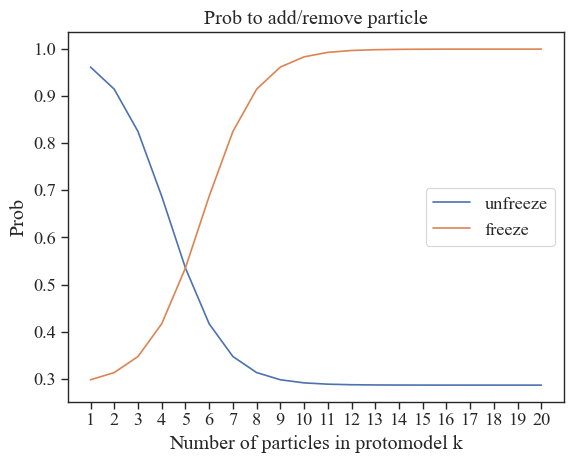

In [4]:
n_par = np.arange(1,21)

nd1 = 1
ns1 = 1
nd2 = nd1 + 2
ns2 = ns1 + 2
prob_list_add, prob_list_rem = [],[]
deg_of_freedom = []

#example case: Adding/removing a particle with 2 extra decay modes and 2 extra prod modes 
for np1 in n_par:
    np2 = np1 + 1 
    
    prob_add = prop_add(np1, nd1, ns1, np2, nd2, ns2)
    #if np1 == 20: prob_add = 0
    prob_list_add.append(prob_add)
    
    deg_of_freedom.append(np1 + nd1 + ns1)

    prob_rem = prop_rem(np1, nd1, ns1, np2, nd2, ns2)
    #if np1 == 1: prob_rem = 0
    prob_list_rem.append(prob_rem)

    #updating decay and prod modes
    nd1 = nd1 + 1
    ns1 = ns1 + 1
    nd2 = nd1 + 2
    ns2 = ns1 + 2

plt.plot(n_par, prob_list_add, label='unfreeze')
plt.plot(n_par, prob_list_rem, label='freeze')
plt.xticks(ticks=n_par)
plt.xlabel("Number of particles in protomodel k")
plt.ylabel("Prob")
plt.legend()
plt.title("Prob to add/remove particle")
plt.show()

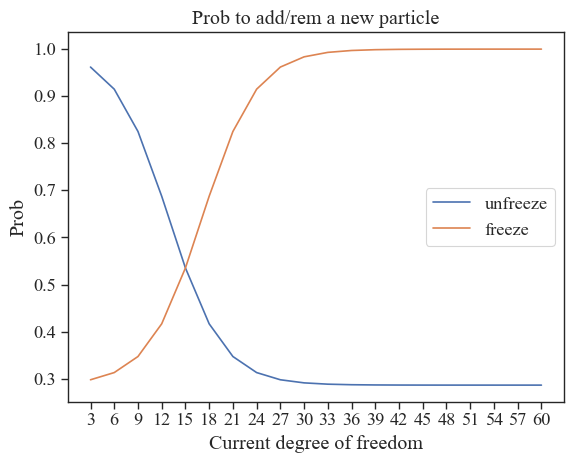

In [5]:
plt.plot(deg_of_freedom, prob_list_add, label='unfreeze')
plt.plot(deg_of_freedom, prob_list_rem, label='freeze')
#plt.plot(n_par, , label='freeze')
plt.xticks(ticks=deg_of_freedom)
plt.xlabel("Current degree of freedom")
plt.ylabel("Prob")
plt.legend()
plt.title("Prob to add/rem a new particle")
plt.show()